In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
df = pd.read_csv('cleaned_cognitive_fatigue_dataset.csv')
print(df.shape)

(98535, 4)


In [4]:
df.head()

,screen_time,sleep_hours,stress_level,wellness_index
0,10.79,6.63,9.3,9.3
1,7.40,8.05,5.7,56.2
2,9.78,6.48,9.1,3.6
3,11.13,6.89,10.0,0.0
4,13.22,5.79,10.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98535 entries, 0 to 98534
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   screen_time     98535 non-null  float64
 1   sleep_hours     98535 non-null  float64
 2   stress_level    98535 non-null  float64
 3   wellness_index  98535 non-null  float64
dtypes: float64(4)
memory usage: 3.0 MB


In [6]:
df.dtypes

screen_time       float64
sleep_hours       float64
stress_level      float64
wellness_index    float64
dtype: object

In [8]:
df.isnull().sum()

screen_time       0
sleep_hours       0
stress_level      0
wellness_index    0
dtype: int64

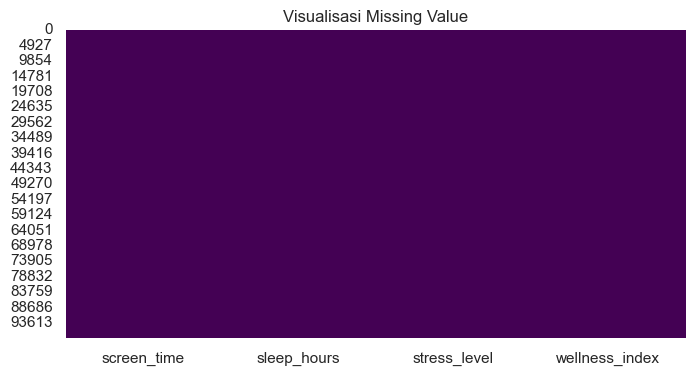

In [9]:
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Visualisasi Missing Value')
plt.show()

In [10]:
df.describe()

,screen_time,sleep_hours,stress_level,wellness_index
count,98535.000000,98535.000000,98535.000000,98535.000000
mean,6.029388,0.594462,0.608154,0.960015
std,2.002610,0.463438,0.548868,1.798835
min,1.000000,0.000000,0.000000,0.000000
25%,4.700000,0.428571,0.444444,0.750000
50%,6.000000,0.571429,0.555556,1.000000
75%,7.400000,0.714286,0.777778,1.000000
max,19.170000,9.740000,10.000000,97.000000


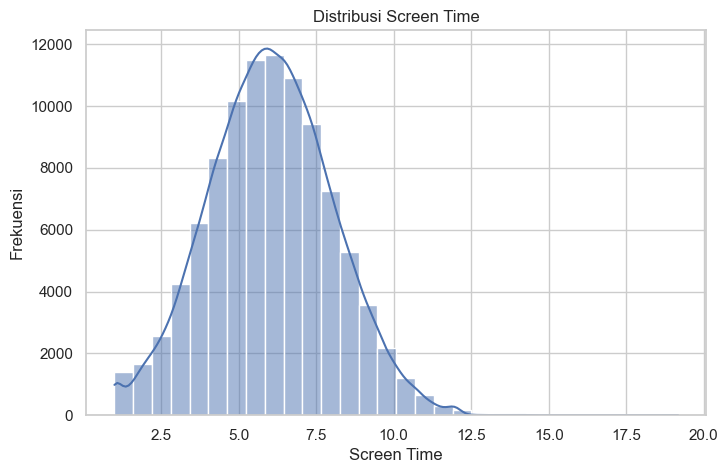

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['screen_time'], bins=30, kde=True)
plt.title('Distribusi Screen Time')
plt.xlabel('Screen Time')
plt.ylabel('Frekuensi')
plt.show()

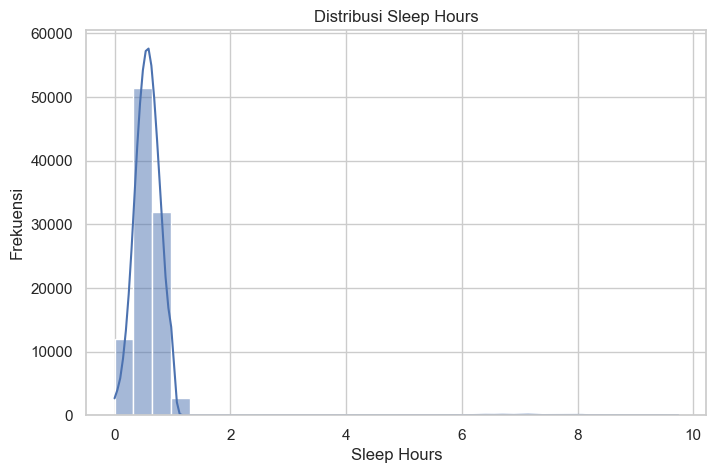

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['sleep_hours'], bins=30, kde=True)
plt.title('Distribusi Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Frekuensi')
plt.show()

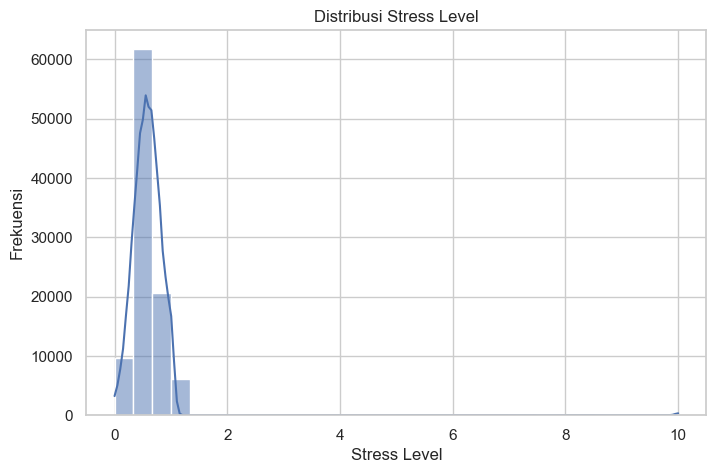

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['stress_level'], bins=30, kde=True)
plt.title('Distribusi Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Frekuensi')
plt.show()

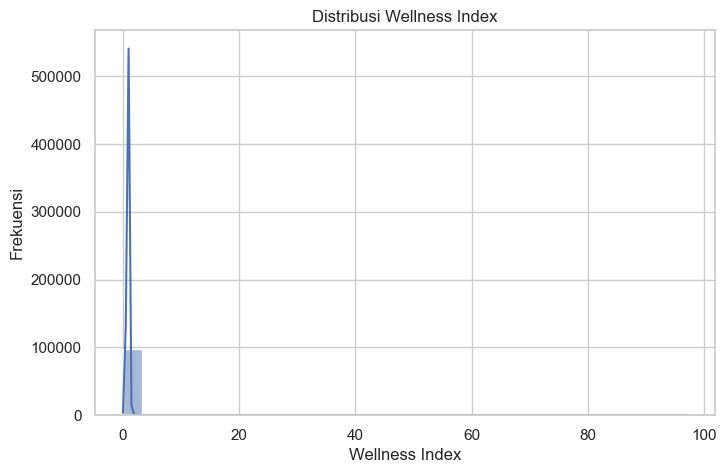

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['wellness_index'], bins=30, kde=True)
plt.title('Distribusi Wellness Index')
plt.xlabel('Wellness Index')
plt.ylabel('Frekuensi')
plt.show()

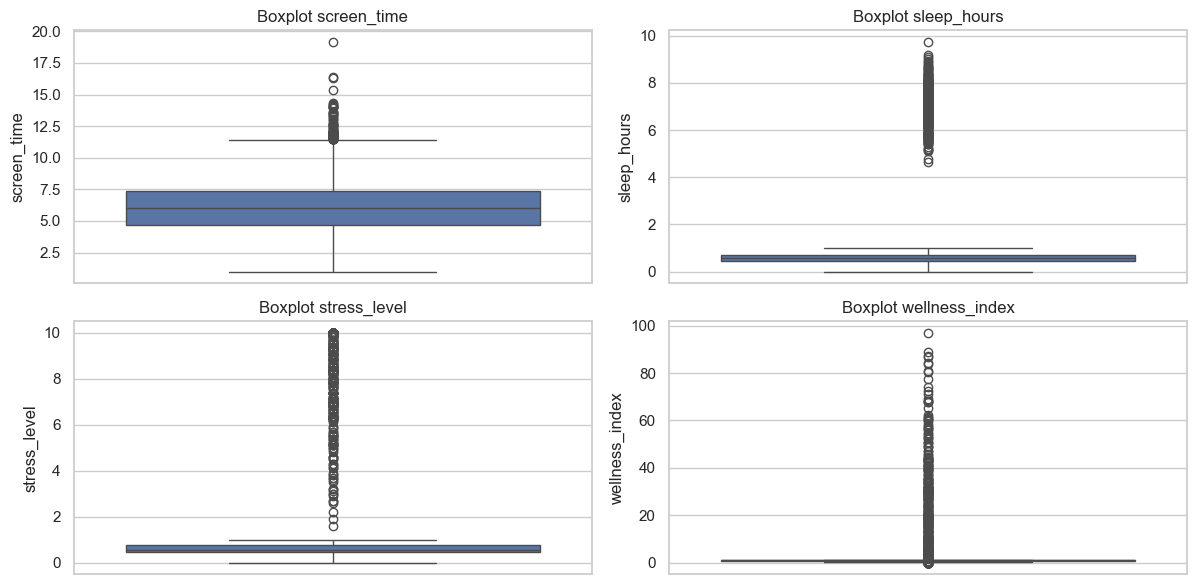

In [15]:
plt.figure(figsize=(12,6))

for i, column in enumerate(df.columns, 1):
    plt.subplot(2,2,i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot {column}')

plt.tight_layout()
plt.show()

In [16]:
print("Jumlah Outlier Setiap Kolom:\n")

for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f'{column}: {len(outlier)} outlier')

Jumlah Outlier Setiap Kolom:

screen_time: 358 outlier
sleep_hours: 400 outlier
stress_level: 397 outlier
wellness_index: 792 outlier



Matriks Korelasi:
                screen_time  sleep_hours  stress_level  wellness_index
screen_time        1.000000     0.082649      0.299428       -0.000774
sleep_hours        0.082649     1.000000      0.632896        0.683415
stress_level       0.299428     0.632896      1.000000        0.419641
wellness_index    -0.000774     0.683415      0.419641        1.000000


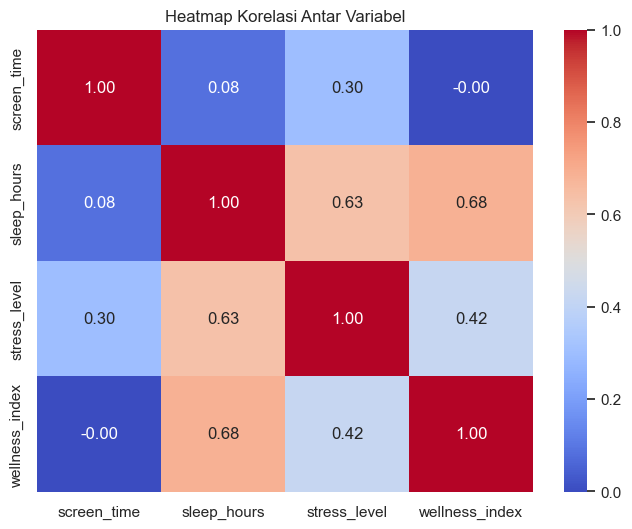

In [17]:
correlation = df.corr()

print("\nMatriks Korelasi:")
print(correlation)

# Heatmap korelasi
plt.figure(figsize=(8,6))
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Heatmap Korelasi Antar Variabel')
plt.show()

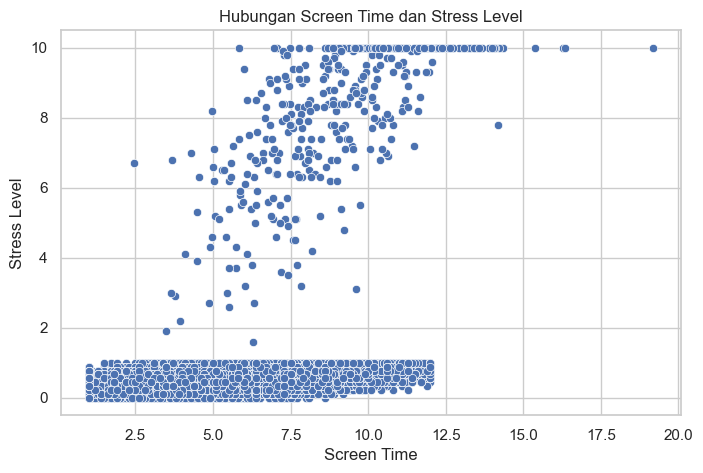

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='screen_time',
                y='stress_level',
                data=df)

plt.title('Hubungan Screen Time dan Stress Level')
plt.xlabel('Screen Time')
plt.ylabel('Stress Level')
plt.show()

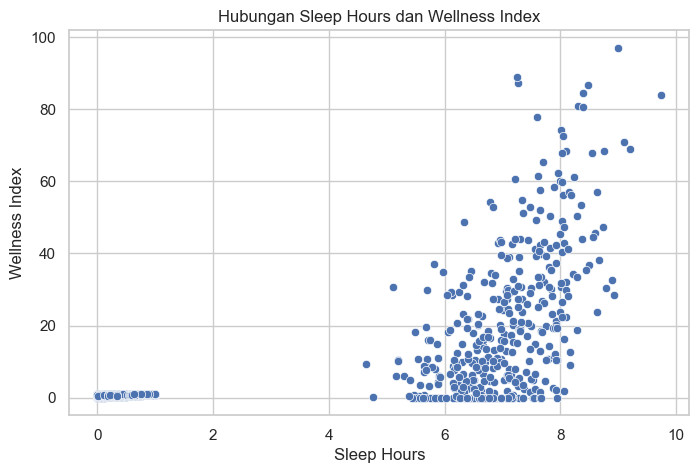

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='sleep_hours',
                y='wellness_index',
                data=df)

plt.title('Hubungan Sleep Hours dan Wellness Index')
plt.xlabel('Sleep Hours')
plt.ylabel('Wellness Index')
plt.show()

In [20]:
for column in df.columns:
    print(f"\nJumlah nilai unik pada {column}:")
    print(df[column].nunique())


Jumlah nilai unik pada screen_time:
398

Jumlah nilai unik pada sleep_hours:
301

Jumlah nilai unik pada stress_level:
82

Jumlah nilai unik pada wellness_index:
270


In [21]:
df.duplicated().sum()

np.int64(56483)

In [22]:
for column in df.columns:
    print(f'{column}')
    print(f'Minimum : {df[column].min()}')
    print(f'Maksimum: {df[column].max()}')
    print('-'*30)

screen_time
Minimum : 1.0
Maksimum: 19.17
------------------------------
sleep_hours
Minimum : 0.0
Maksimum: 9.74
------------------------------
stress_level
Minimum : 0.0
Maksimum: 10.0
------------------------------
wellness_index
Minimum : 0.0
Maksimum: 97.0
------------------------------


In [23]:
mean_values = df.mean()

print("\nRata-rata Setiap Variabel:")
print(mean_values)


Rata-rata Setiap Variabel:
screen_time       6.029388
sleep_hours       0.594462
stress_level      0.608154
wellness_index    0.960015
dtype: float64


In [24]:
median_values = df.median()

print("\nMedian Setiap Variabel:")
print(median_values)


Median Setiap Variabel:
screen_time       6.000000
sleep_hours       0.571429
stress_level      0.555556
wellness_index    1.000000
dtype: float64


In [25]:
std_values = df.std()

print("\nStandar Deviasi:")
print(std_values)


Standar Deviasi:
screen_time       2.002610
sleep_hours       0.463438
stress_level      0.548868
wellness_index    1.798835
dtype: float64


In [26]:
df.skew()

screen_time        0.060595
sleep_hours       11.312379
stress_level      12.654892
wellness_index    29.046269
dtype: float64

In [27]:
df.kurtosis()

screen_time        -0.103069
sleep_hours       162.454820
stress_level      197.087106
wellness_index    999.423794
dtype: float64

In [29]:
df.to_csv('hasil_eda_dataset.csv', index=False)


In [30]:
df = pd.read_csv('hasil_eda_dataset.csv')
print(df.shape)

(98535, 4)
